In [68]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [69]:
conn = sqlite3.connect('/Users/bakarybengaly/Documents/Analyse_avec_SQL/travel.sqlite')
print("Connexion réussie !")


Connexion réussie !


In [70]:
def sql(query):
    return pd.read_sql_query(query, conn)

In [71]:
sql("""
    SELECT * FROM bookings
""")


,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600
...,...,...,...
262783,FFFEF3,2017-07-17 07:23:00+03,56000
262784,FFFF2C,2017-08-08 05:55:00+03,10800
262785,FFFF43,2017-07-20 20:42:00+03,78500
262786,FFFFA8,2017-08-08 04:45:00+03,28800


In [72]:
sql ( """SELECT A.aircraft_code, json_extract(model, '$.en') AS model_avion ,S.fare_conditions , count (seat_no) AS nombre_de_siege
FROM aircrafts_data A , seats S
WHERE A.aircraft_code = S.aircraft_code 
GROUP BY A.aircraft_code, json_extract(model, '$.en'), S.fare_conditions """ )

,aircraft_code,model_avion,fare_conditions,nombre_de_siege
0,319,Airbus A319-100,Business,20
1,319,Airbus A319-100,Economy,96
2,320,Airbus A320-200,Business,20
3,320,Airbus A320-200,Economy,120
4,321,Airbus A321-200,Business,28
5,321,Airbus A321-200,Economy,142
6,733,Boeing 737-300,Business,12
7,733,Boeing 737-300,Economy,118
8,763,Boeing 767-300,Business,30
9,763,Boeing 767-300,Economy,192


In [73]:
 sql (""" SELECT  flight_id ,  count(boarding_no) AS nb_passagers_embarqué
FROM boarding_passes
GROUP BY flight_id """)

,flight_id,nb_passagers_embarqué
0,1,79
1,2,101
2,3,97
3,17,101
4,18,96
...,...,...
11513,33115,20
11514,33116,17
11515,33117,16
11516,33118,16


In [74]:
sql (""" SELECT A.aircraft_code,
 json_extract(model, '$.en') AS model_avion , 
count(boarding_no) AS nb_passagers_embarqué 
FROM aircrafts_data A , boarding_passes B  , flights F
WHERE F.aircraft_code = A.aircraft_code
AND F.flight_id = B.flight_id
GROUP BY json_extract(model, '$.en')
""")

,aircraft_code,model_avion,nb_passagers_embarqué
0,319,Airbus A319-100,29310
1,321,Airbus A321-200,57726
2,733,Boeing 737-300,47752
3,763,Boeing 767-300,69046
4,773,Boeing 777-300,82127
5,CR2,Bombardier CRJ-200,83912
6,CN1,Cessna 208 Caravan,8130
7,SU9,Sukhoi Superjet-100,201683


In [75]:
sql ("""
    
SELECT aircraft_code, ROUND(AVG(taux_par_vol), 2) AS taux_moyen_occupation
FROM (SELECT P.flight_id , P.aircraft_code, (P.nb_passagers * 100.0 / C.nb_sieges) AS taux_par_vol
FROM (SELECT F.flight_id , F.aircraft_code, count (B.boarding_no) AS nb_passagers
FROM flights F, boarding_passes B
WHERE F.flight_id = B.flight_id
GROUP BY  F.flight_id , F.aircraft_code) AS P 
JOIN (SELECT aircraft_code , count (seat_no) AS nb_sieges
FROM seats
GROUP BY aircraft_code) AS C
ON P.aircraft_code = C.aircraft_code) AS t
GROUP BY aircraft_code
ORDER BY taux_moyen_occupation DESC
""")

,aircraft_code,taux_moyen_occupation
0,773,65.90
1,733,61.73
2,SU9,58.57
3,321,52.24
4,763,51.32
5,CN1,50.04
6,319,46.19
7,CR2,42.97


In [76]:
sql ("""
    SELECT t.aircraft_code, ROUND(AVG(taux_par_vol), 2) AS taux_moyen_occupation, json_extract(a.model, '$.en') AS model_avion
FROM (SELECT P.flight_id , P.aircraft_code, (P.nb_passagers * 100.0 / C.nb_sieges) AS taux_par_vol
FROM (SELECT F.flight_id , F.aircraft_code, count (B.boarding_no) AS nb_passagers
FROM flights F, boarding_passes B
WHERE F.flight_id = B.flight_id
GROUP BY  F.flight_id , F.aircraft_code) AS P 
JOIN (SELECT aircraft_code , count (seat_no) AS nb_sieges
FROM seats
GROUP BY aircraft_code) AS C
ON P.aircraft_code = C.aircraft_code) AS t
JOIN aircrafts_data a ON t.aircraft_code = a.aircraft_code
GROUP BY t.aircraft_code
ORDER BY taux_moyen_occupation DESC
""")

,aircraft_code,taux_moyen_occupation,model_avion
0,773,65.90,Boeing 777-300
1,733,61.73,Boeing 737-300
2,SU9,58.57,Sukhoi Superjet-100
3,321,52.24,Airbus A321-200
4,763,51.32,Boeing 767-300
5,CN1,50.04,Cessna 208 Caravan
6,319,46.19,Airbus A319-100
7,CR2,42.97,Bombardier CRJ-200


In [77]:
sql  ("""
   SELECT F.aircraft_code, json_extract (A.model,  '$.en') AS model_avion , ROUND(AVG(T.amount), 2 )AS revenu_moyen
FROM ticket_flights  T , flights F , aircrafts_data A 
WHERE T.flight_id = F.flight_id
AND A.aircraft_code = F.aircraft_code
GROUP BY F.aircraft_code
ORDER BY AVG(T.amount) DESC
""")

,aircraft_code,model_avion,revenu_moyen
0,319,Airbus A319-100,51201.69
1,763,Boeing 767-300,35033.56
2,773,Boeing 777-300,23765.76
3,733,Boeing 737-300,16568.16
4,321,Airbus A321-200,15291.51
5,SU9,Sukhoi Superjet-100,13985.54
6,CR2,Bombardier CRJ-200,13207.66
7,CN1,Cessna 208 Caravan,6568.55


In [78]:
sql("""
    SELECT taux.aircraft_code,
       taux.model_avion,
       taux.taux_moyen_occupation,
       revenu.revenu_moyen
FROM (
  SELECT t.aircraft_code, ROUND(AVG(taux_par_vol), 2) AS taux_moyen_occupation, json_extract(a.model, '$.en') AS model_avion
FROM (SELECT P.flight_id , P.aircraft_code, (P.nb_passagers * 100.0 / C.nb_sieges) AS taux_par_vol
FROM (SELECT F.flight_id , F.aircraft_code, count (B.boarding_no) AS nb_passagers
FROM flights F, boarding_passes B
WHERE F.flight_id = B.flight_id
GROUP BY  F.flight_id , F.aircraft_code) AS P 
JOIN (SELECT aircraft_code , count (seat_no) AS nb_sieges
FROM seats
GROUP BY aircraft_code) AS C
ON P.aircraft_code = C.aircraft_code) AS t
JOIN aircrafts_data a ON t.aircraft_code = a.aircraft_code
GROUP BY t.aircraft_code
ORDER BY taux_moyen_occupation DESC
) AS taux
JOIN (
   SELECT F.aircraft_code, json_extract (A.model,  '$.en') AS model_avion , ROUND(AVG(T.amount), 2 )AS revenu_moyen
FROM ticket_flights  T , flights F , aircrafts_data A 
WHERE T.flight_id = F.flight_id
AND A.aircraft_code = F.aircraft_code
GROUP BY F.aircraft_code
ORDER BY AVG(T.amount) DESC
) AS revenu
ON taux.aircraft_code = revenu.aircraft_code
ORDER BY taux.taux_moyen_occupation DESC
""")

,aircraft_code,model_avion,taux_moyen_occupation,revenu_moyen
0,773,Boeing 777-300,65.90,23765.76
1,733,Boeing 737-300,61.73,16568.16
2,SU9,Sukhoi Superjet-100,58.57,13985.54
3,321,Airbus A321-200,52.24,15291.51
4,763,Boeing 767-300,51.32,35033.56
5,CN1,Cessna 208 Caravan,50.04,6568.55
6,319,Airbus A319-100,46.19,51201.69
7,CR2,Bombardier CRJ-200,42.97,13207.66


In [79]:
sql ("""
    SELECT substr(scheduled_departure, 6, 2) AS mois, 
    COUNT(B.boarding_no) AS nb_passagers , 
    COUNT(DISTINCT F.flight_id) AS nb_vols,
    ROUND(COUNT(B.boarding_no) * 1.0 / COUNT(DISTINCT F.flight_id), 2) AS moy_passagers_par_vol
FROM flights F
JOIN boarding_passes B ON F.flight_id = B.flight_id
GROUP BY substr(scheduled_departure, 6, 2)
ORDER BY mois
""")

,mois,nb_passagers,nb_vols,moy_passagers_par_vol
0,07,250854,5765,43.51
1,08,328832,5753,57.16


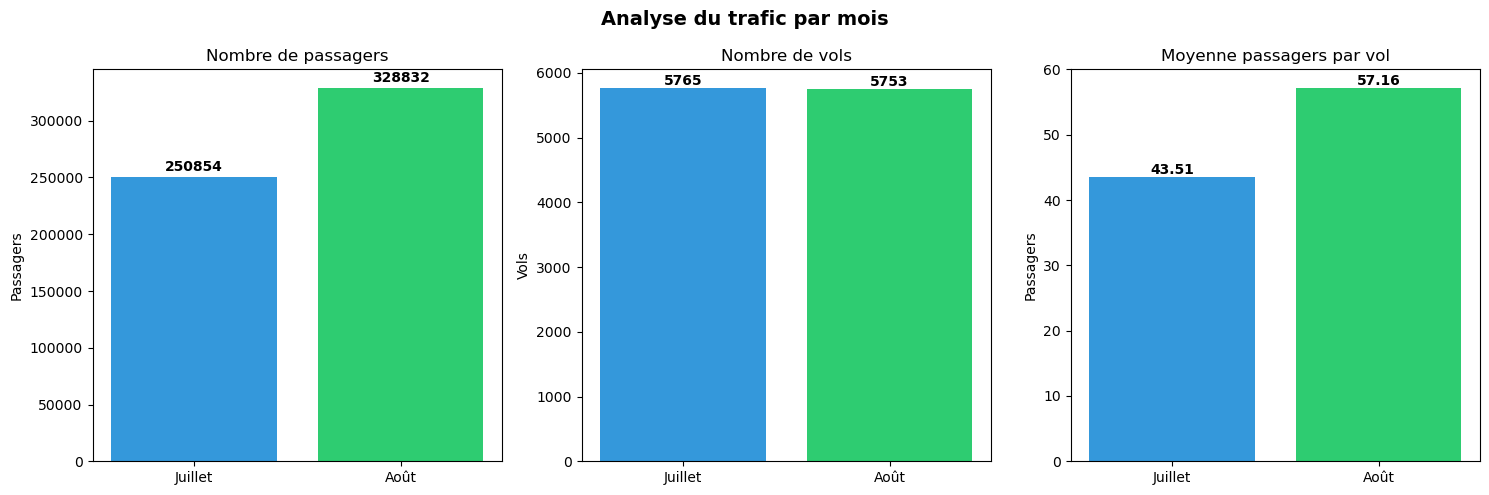

In [80]:

mois = ['Juillet', 'Août']
nb_passagers = [250854, 328832]
nb_vols = [5765, 5753]
moy_par_vol = [43.51, 57.16]

# Création du graphique
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Analyse du trafic par mois", fontsize=14, fontweight='bold')

# Graphique 1 — Passagers
axes[0].bar(mois, nb_passagers, color=['#3498db', '#2ecc71'])
axes[0].set_title("Nombre de passagers")
axes[0].set_ylabel("Passagers")
for i, v in enumerate(nb_passagers):
    axes[0].text(i, v + 5000, str(v), ha='center', fontweight='bold')


# Graphique 2 — Vols
axes[1].bar(mois, nb_vols, color=['#3498db', '#2ecc71'])
axes[1].set_title("Nombre de vols")
axes[1].set_ylabel("Vols")
for i, v in enumerate(nb_vols):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')


# Graphique 3 — Moyenne passagers par vol
axes[2].bar(mois, moy_par_vol, color=['#3498db', '#2ecc71'])
axes[2].set_title("Moyenne passagers par vol")
axes[2].set_ylabel("Passagers")
for i, v in enumerate(moy_par_vol):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

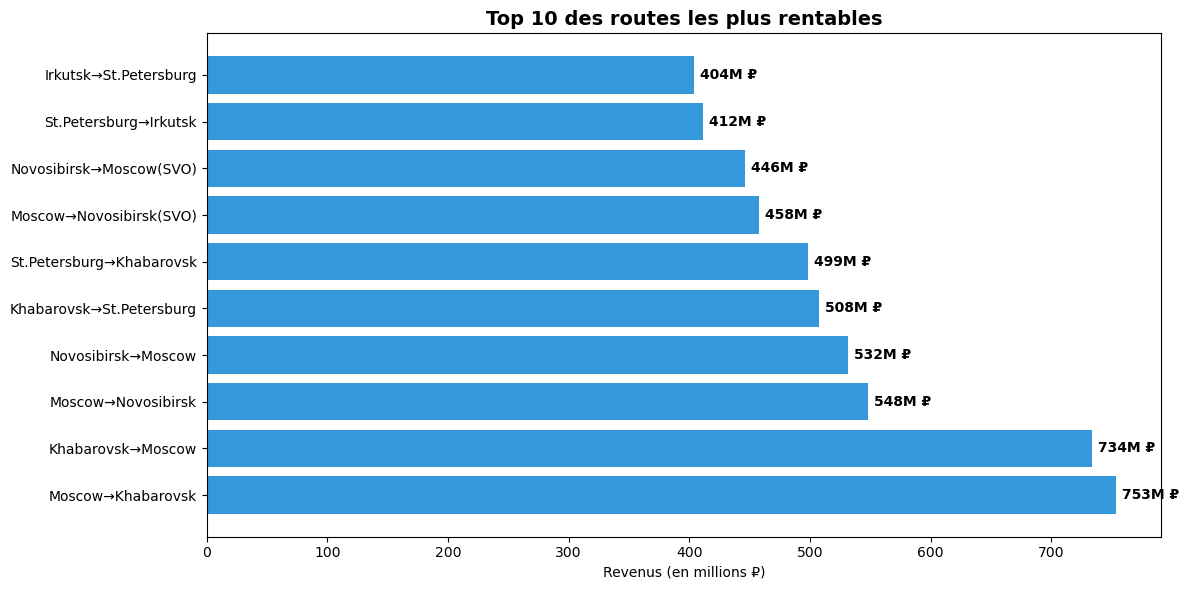

In [81]:
sql ("""
   SELECT json_extract(AD.city, '$.en') AS ville_depart, json_extract(AA.city, '$.en') AS ville_arrivee, COUNT(F.flight_no) AS nb_vol,SUM(T.amount) AS sum_total
FROM flights F,ticket_flights T , airports_data AD, airports_data AA
WHERE F.flight_id = T.flight_id 
AND F.departure_airport = AD.airport_code
AND F.arrival_airport = AA.airport_code
GROUP BY F.departure_airport , F.arrival_airport
ORDER BY SUM(T.amount) DESC  LIMIT 10

""")


# Données
routes = [
    'Moscow→Khabarovsk', 'Khabarovsk→Moscow', 'Moscow→Novosibirsk',
    'Novosibirsk→Moscow', 'Khabarovsk→St.Petersburg', 'St.Petersburg→Khabarovsk',
    'Moscow→Novosibirsk(SVO)', 'Novosibirsk→Moscow(SVO)', 
    'St.Petersburg→Irkutsk', 'Irkutsk→St.Petersburg'
]
revenus = [753478300, 733797800, 548218900, 531503700, 507672400,
           498750700, 458130400, 446051200, 411603000, 404050300]

# Conversion en millions
revenus_millions = [r / 1_000_000 for r in revenus]

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(routes, revenus_millions, color='#3498db')
ax.set_xlabel('Revenus (en millions ₽)')
ax.set_title('Top 10 des routes les plus rentables', fontsize=14, fontweight='bold')

# Valeurs sur les barres
for i, v in enumerate(revenus_millions):
    ax.text(v + 5, i, f'{v:.0f}M ₽', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

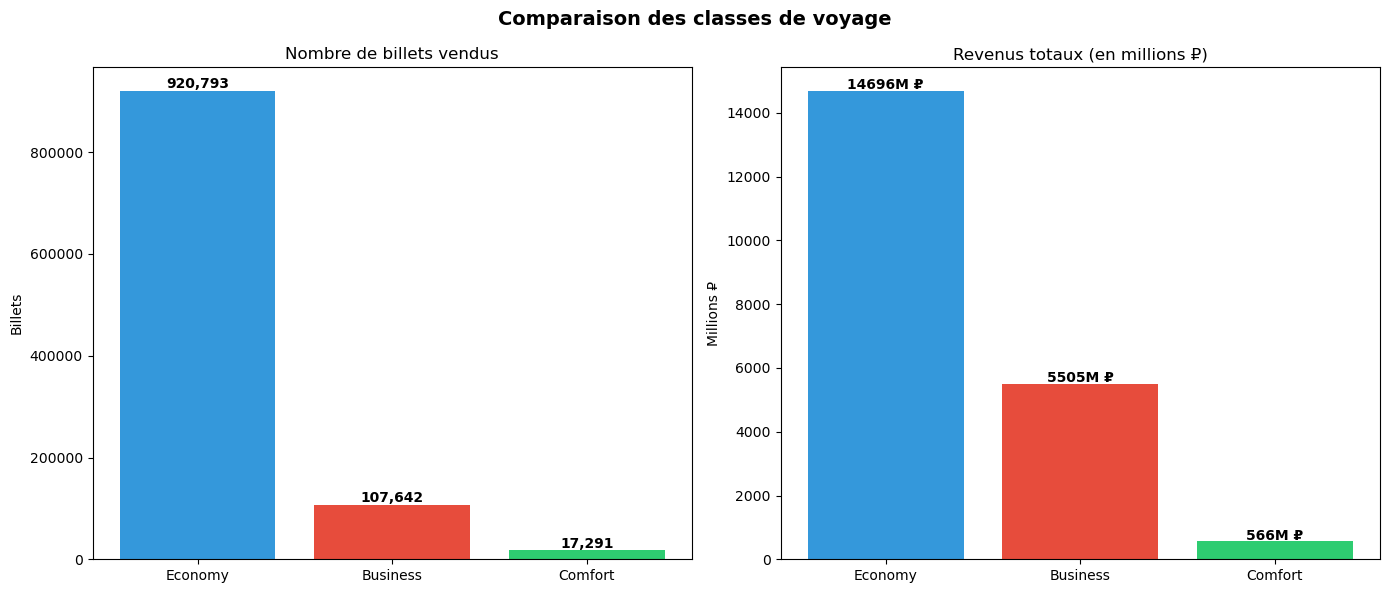

In [82]:
sql("""
    SELECT  T.fare_conditions, count(T.amount) AS nb_billets,CAST(ROUND(SUM(T.amount), 2) AS INTEGER) AS revenu_total
FROM ticket_flights T 
GROUP BY fare_conditions 
ORDER BY (revenu_total) DESC

""")

classes = ['Economy', 'Business', 'Comfort']
nb_billets = [920793, 107642, 17291]
revenus = [14695684400, 5505179600, 566116900]
revenus_millions = [r / 1_000_000 for r in revenus]
couleurs = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparaison des classes de voyage', fontsize=14, fontweight='bold')

# Graphique 1 — Nombre de billets
bars1 = axes[0].bar(classes, nb_billets, color=couleurs)
axes[0].set_title('Nombre de billets vendus')
axes[0].set_ylabel('Billets')
for i, v in enumerate(nb_billets):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Graphique 2 — Revenus
bars2 = axes[1].bar(classes, revenus_millions, color=couleurs)
axes[1].set_title('Revenus totaux (en millions ₽)')
axes[1].set_ylabel('Millions ₽')
for i, v in enumerate(revenus_millions):
    axes[1].text(i, v + 50, f'{v:.0f}M ₽', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()